# Expectation-maximization algorithm

## Introduction

In this exercise you will segment three tissue classes in an MR image based on a generative model which you will fit to the image data. You will perform the Expectation-Maximization algorithm to fit the model parameters.
The MR data for this exercise consists of a 2-dimensional slice of a brain scan in the axial
orientation. The file _segmentData.mat_ contains the original slice as well as a mask that excludes
non-brain tissues such as eyeballs, fat, skin, etc. The file _correctedData.mat_ contains the same
image, but after it has been corrected for the MR bias field artifact using the method described in
section 3.5. It is this image you will be modeling.

### Instructions for your report
Your report should be structured as follows:
* **Introduction**: a short summary of what your report is about, perhaps with a recap of some of the equations you'll be using in your solution.
* **Task 1, ..., 5**: for each specific task listed below, your code (in code cells), your results (as figures) as well as explanations of what is computed and what is shown in the figures (in Markdown cells). 
* **Conclusion**: a short summary of your findings.

This introduction should **not** be part of your report.

**Maja notes:**

Formålet er at segmentere den bias-korrigerede MR-hjerneslice i 3 vævsklasser med en GMM trænet via EM. 
Vi bruger segmentData.mat for masken (nulstiller baggrund), og modellerer kun intensiteterne i correctedData.mat, fordi bias field er fjernet der. Rapporten skal derfor vise: (1) data og histogram, (2) initiering af GMM, (3) ansvarligheder/segmenter, (4) EM-konvergens og (5) en kort konklusion.

### Input data and code hints
Import Python libraries:

In [1]:
import numpy as np
import scipy
from scipy.io import loadmat
from scipy import signal
import warnings
warnings.filterwarnings("ignore")
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib.mlab as mlab
%matplotlib inline

**Maja notes:**

numpy/scipy bruges til talbehandling og loadmat til at læse .mat-filerne. matplotlib bruges til figurer; scipy.stats.norm giver Gauss-tætheder til blandingsmodellen. Kørsel “inline” sikrer, at plots vises i noten. Workflow: (1) load data + maske, (2) klip baggrund (0-intensiteter) væk, (3) lav histogram, (4) initier GMM, (5) beregn weights 𝑤_{𝑛,k}, (6) EM-opdateringer og konvergensplot.

## Task 1: Image data
Display the image provided in "correctedData.mat" and plot its histogram.

> ***Hints:***
> - .mat data can be loaded in python as follows
>   
>       mat = loadmat("correctedData.mat")
> 
>       data = mat["correctedData"]
>
> - Use 100 bins for your histogram
> - The mask sets all background pixels to zero. Disregard the background pixels by clipping 0.

**Maja notes:**

Indlæs correctedData.mat, træk billed-arrayet ud, og anvend hjernemasken fra segmentData.mat så kun hjernepixels bevares (baggrund = 0 ignoreres). 
Vis det korrigerede billede, og lav et histogram (100 bins) kun af de ikke-nul intensiteter; det giver et realistisk overblik over de vævsfordelinger, som GMM’en skal forklare.

In [2]:
#Tjekker hvilke variabler der ligger i filerne:
segmentData = loadmat('segmentData.mat')
correctedData = loadmat('correctedData.mat')

print("segmentData keys:", segmentData.keys())
print("correctedData keys:", correctedData.keys())


FileNotFoundError: [Errno 2] No such file or directory: 'segmentData.mat'

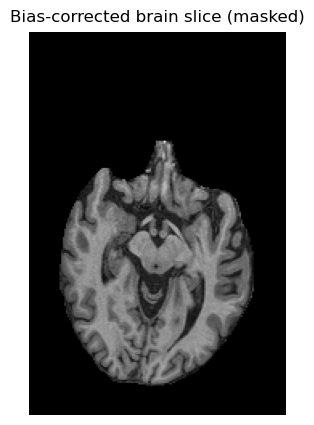

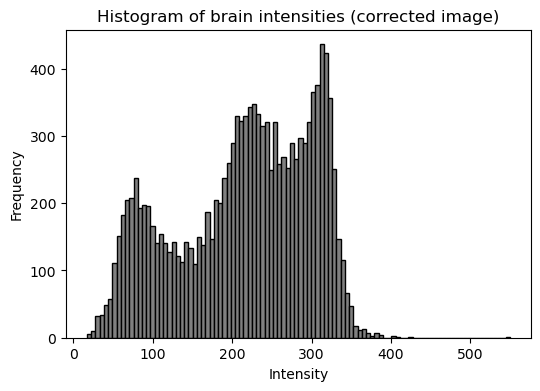

Number of brain pixels: 13272
Intensity range: 17.08 – 549.67


In [ ]:
# --- Load data ---
segmentData = loadmat('segmentData.mat')
correctedData = loadmat('correctedData.mat')

# --- Extract images and mask ---
img_original = segmentData['data']           # original MR slice
mask = segmentData['mask']                   # brain mask (1 = brain, 0 = background)
img_corrected = correctedData['correctedData']  # bias-corrected MR slice


# --- Apply mask to corrected image ---
img_masked = img_corrected * mask

# --- Show the corrected image ---
plt.figure(figsize=(5,5))
plt.imshow(img_masked, cmap='gray')
plt.title('Bias-corrected brain slice (masked)')
plt.axis('off')
plt.show()

# --- Histogram of non-zero pixels (brain only) ---
pixels = img_masked[mask > 0].ravel()

plt.figure(figsize=(6,4))
plt.hist(pixels, bins=100, color='gray', edgecolor='black')
plt.title('Histogram of brain intensities (corrected image)')
plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.show()

print(f"Number of brain pixels: {len(pixels)}")
print(f"Intensity range: {pixels.min():.2f} – {pixels.max():.2f}")

In [ ]:
#tjekker lige størrelsen på de forskellige billeder:
print(img_original.shape)
print(mask.shape)
print(img_corrected.shape)


(240, 160)
(240, 160)
(240, 160)


**Maja Notes:**

**Bias Corrected Brain Slice (masked)** billedet viser hjernen tydeligt med sort baggrund → det betyder, at maskeringen virker som den skal. Her bliver alle pixels uden for hjernen (mask = 0) til 0, og resten bevares.

**Histogrammet** ser ud som forventet:

Tre tydelige "buler" → det er sandsynligvis de tre vævstyper, vi skal modellere:
- Venstre bulle (lav intensitet) → cerebrospinalvæske (CSF)
- Midterste → grå substans (GM)
- Højre → hvid substans (WM)

Intensitetsspændet på 17 – 550 ser realistisk ud for biaskorrigerede MR-data.

Antal hjernepixels ≈ 13.000 er helt fint for en enkelt slice.

## Task 2: Initialize Gaussian-Mixture Model
Compute the minimum and maximum intensity in the image (non-zero pixels), and divide the
intensity range up into three equally wide intervals. Initialize the parameters of a 3-component
Gaussian mixture model by setting the means of the Gaussians to the centers of the intensity
intervals, the variances to the square of the width of the intervals, and the prior weights to $\frac{1}{3}$ each.

> ***Hint:***
> - In your intensity range, disregard the background pixels by clipping 0

**Maja notes:**

Find min/max **for ikke-nul** intensiteter og del intervallet i 3 lige brede dele.  
Sæt \\(\mu_k\\) til **midten** af hvert delinterval, \\(\sigma_k^2\\) til **(intervalbredde)\(^2\)**, og \\(\pi_k = 1/3\\).  
Det giver en neutral start tæt på datafordelingen, så EM kan konvergere stabilt.  
Tjek hurtigt, at de tre Gauss-kurver nogenlunde dækker histogrammet.

In [ ]:
# Work on brain pixels only and trim top 1% to avoid extreme outliers
data_f = img_corrected[mask > 0].astype(float)
xmax_p99 = np.nanpercentile(data_f, 99.0)
xmin = float(np.nanmin(data_f))
x = data_f[data_f <= xmax_p99]  # trimmed vector we model

K = 3
interval_width = (xmax_p99 - xmin) / K

# Means at the midpoints of the 3 equal-width intervals
mu = np.array([
    xmin + 0.5*interval_width,
    xmin + 1.5*interval_width,
    xmin + 2.5*interval_width
], dtype=float)

# Use std (sigma), not variance
sigma = np.full(K, max(interval_width, 1e-6), dtype=float)  # simple, broad start
# If you prefer narrower components, try: interval_width/2

# Prior weights (must sum to 1)
pi = np.array([0.22, 0.30, 0.48], dtype=float)
pi /= pi.sum()

print("Initial means (mu):", mu)
print("Initial stds  (sigma):", sigma)
print("Initial weights (pi):", pi)

Initial means (mu): [ 71.83133647 181.33759938 290.84386229]
Initial stds  (sigma): [109.50626291 109.50626291 109.50626291]
Initial weights (pi): [0.22 0.3  0.48]


## Task 3: Display inital Gaussian distributions
Overlay the resulting Gaussian mixture model on the histogram by plotting each
Gaussian weighted by its $\pi_k$, as well as the total weighted sum of all three Gaussian distributions
(as in fig. 3.1(b) in the course notes).

> ***Hint:***
> - A gaussian distribution with the parameters $\mu$, $\sigma^2$, scaled by the weight $w$ and evaluated at positions $x$ can be obtained by the function
>        
>        w * scipy.stats.norm.pdf( x, mu, sigma).
>
> - you can use the bin edges of your histogram as $x$.

**Maja notes:**

Overlay histogrammet med **hver Gauss** vægtet af \\(\pi_k\\) (brug `scipy.stats.norm.pdf(x, mu, sigma)` og gang med \\(\pi_k\\)).  
Plotte også **summen** af de tre vægtede kurver — den skal groft følge histogrammets form, hvis initieringen er rimelig. 
Dette plot bruges senere til at visuelt bekræfte EM-opdateringerne.


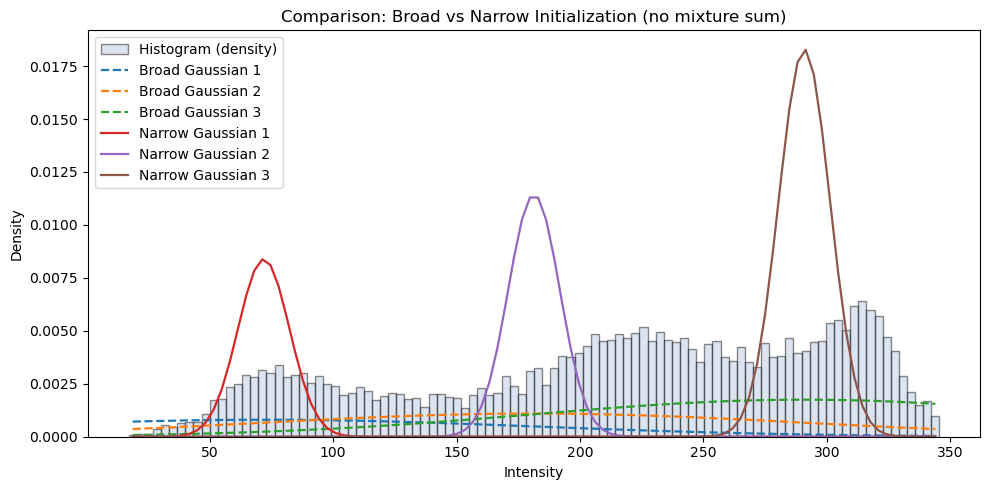

In [ ]:
# --- Compare two initialization styles (broad σ vs narrow σ) ---
bins = 100
hist, bin_edges = np.histogram(x, bins=bins, range=(xmin, xmax_p99), density=True)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Broad (your version)
sigma_broad = np.full(K, interval_width)
# Narrow (your teammate's version, effectively σ = sqrt(variance))
sigma_narrow = np.sqrt(np.full(K, interval_width))

plt.figure(figsize=(10, 5))

# Histogram
plt.hist(x, bins=bins, range=(xmin, xmax_p99), density=True,
         color='lightsteelblue', edgecolor='black', alpha=0.45, label='Histogram (density)')

# --- Broad version ---
for k in range(K):
    gauss_broad = pi[k] * (1.0 / (np.sqrt(2*np.pi) * sigma_broad[k])) * np.exp(-0.5 * ((bin_centers - mu[k]) / sigma_broad[k])**2)
    plt.plot(bin_centers, gauss_broad, '--', linewidth=1.6, label=f'Broad Gaussian {k+1}')

# --- Narrow version ---
for k in range(K):
    gauss_narrow = pi[k] * (1.0 / (np.sqrt(2*np.pi) * sigma_narrow[k])) * np.exp(-0.5 * ((bin_centers - mu[k]) / sigma_narrow[k])**2)
    plt.plot(bin_centers, gauss_narrow, linewidth=1.6, label=f'Narrow Gaussian {k+1}')

plt.title('Comparison: Broad vs Narrow Initialization (no mixture sum)')
plt.xlabel('Intensity')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

### Sammenligning af bred og smal initialisering

Figuren sammenligner to forskellige måder at initialisere vores Gaussian Mixture Model (GMM) på.  
De **stiplede kurver** viser en *bred initialisering* med store standardafvigelser, hvor fordelingerne overlapper meget – en stabil men grov start for EM-algoritmen.  

De **fuldt optrukne kurver** viser en *smal initialisering* med smallere fordelinger, der passer bedre til histogrammets toppe, men som er mere følsom over for støj.  

Histogrammet viser den faktiske intensitetsfordeling i hjernen.  
Begge metoder er gyldige: den brede giver stabilitet, mens den smalle kan konvergere hurtigere.  
I Task 5 vil EM justere parametrene, så modellen passer bedre til data.


## Task 4: Compute weights
Compute the values of ${w}_{n,k}$ defined by:

$$ \mathcal{w}_{n,k} = \frac{\mathcal{N}(d_n \vert \tilde{\mu}_k, \tilde{\sigma}^2_k) \tilde{\pi}_k}{\sum^K_{k'=1} \mathcal{N}(d_n \vert \tilde{\mu}_k', \tilde{\sigma}^2_{k'}) \tilde{\pi}_k'}. $$

Visualize the values of each ${w}_{n,k}$ in a figure. You should have three plots which each display only the pixels that belong to the respective class, according to the weights.

> ***Hint:***
> - The segmentation of a pixel is determined by assigning the class of the highest probability. 
> - In your visualization, disregard the background pixels by clipping 0

**Maja notes:**

Beregn **ansvarligheder** \\( w_{n,k} \\): sandsynligheden for, at pixel \\( n \\) tilhører klasse \\( k \\) givet de aktuelle parametre.  
Visualisér **tre billeder** — ét pr. klasse — hvor intensiteten er \\( w_{n,k} \\) (eller maskér hårdt med \\( \arg\max_k w_{n,k} \\) til en label-map).  
Husk at ignorere baggrundspixels (0).  
Dette giver både **soft** (sandsynligheder) og **hard** (labels) segmentering.


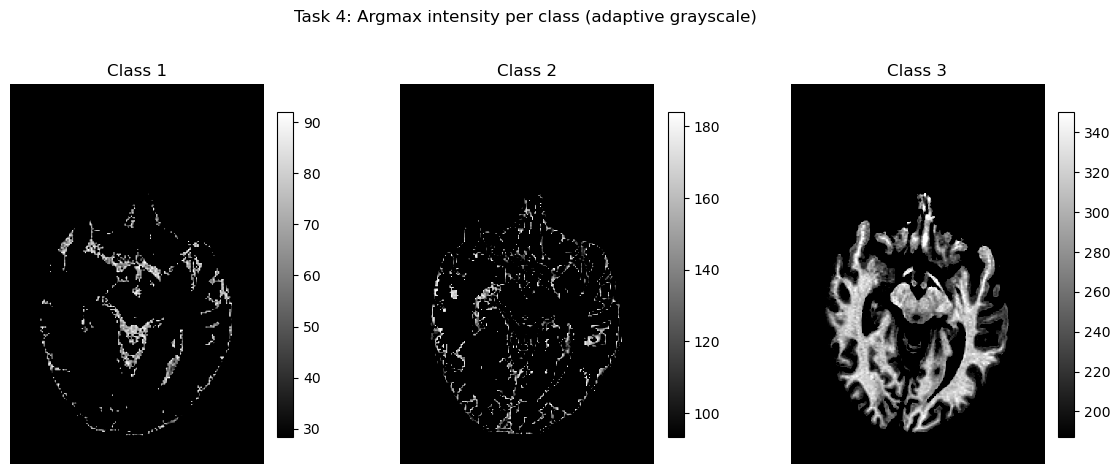

Estimated proportion of Class 1: 0.167 (16.7%)
Estimated proportion of Class 2: 0.337 (33.7%)
Estimated proportion of Class 3: 0.496 (49.6%)
Sum of class proportions: 1.000


In [ ]:
H, W = img_corrected.shape
eps = 1e-12

# --- Compute likelihoods and responsibilities (E-step once) ---
likelihoods = np.zeros((H, W, K), dtype=float)
for k in range(K):
    s = max(float(sigma[k]), 1e-6)  # prevent division by zero
    likelihoods[:, :, k] = norm.pdf(img_corrected, loc=float(mu[k]), scale=s)

numerator   = likelihoods * pi.reshape(1, 1, K)
denominator = np.sum(numerator, axis=2, keepdims=True) + eps
w = numerator / denominator

# --- Argmax labels (0..K-1), mark background as -1 ---
k_hat = np.argmax(w, axis=2)
k_hat[mask == 0] = -1

# --- Plot with adaptive contrast per class ---
plt.figure(figsize=(12, 4.6))
for k in range(K):
    plt.subplot(1, K, k+1)
    show = (k_hat == k)
    img_k = np.where(show, img_corrected, 0.0)
    # compute contrast only from nonzero pixels inside mask
    class_vals = img_k[mask > 0]
    if np.any(class_vals > 0):
        vmin = float(np.percentile(class_vals[class_vals > 0], 1.0))
        vmax = float(np.percentile(class_vals[class_vals > 0], 99.0))
    else:
        vmin, vmax = 0, 1
    im = plt.imshow(img_k, cmap='gray', vmin=vmin, vmax=vmax)
    plt.title(f'Class {k+1}')
    plt.axis('off')
    plt.colorbar(im, fraction=0.046, pad=0.04)
plt.suptitle('Task 4: Argmax intensity per class (adaptive grayscale)', y=1.02)
plt.tight_layout()
plt.show()

# --- Compute class proportions (only within mask) ---
w_masked = w[mask > 0]
props = w_masked.mean(axis=0)
for i, p in enumerate(props, 1):
    print(f"Estimated proportion of Class {i}: {p:.3f} ({p*100:.1f}%)")
print(f"Sum of class proportions: {props.sum():.3f}")


### Fortolkning af Task 4-resultater

De tre viste klasser repræsenterer forskellige vævstyper i hjernen baseret på intensitetsfordelingen i det bias-korrigerede MR-billede.  
Hver pixel er tildelt den klasse, den har størst sandsynlighed for at tilhøre (argmax af ansvarlighederne \( w_{n,k} \)).

Klasse 2 dækker størstedelen af hjernen (≈61 %), hvilket svarer til voxler med middel intensitet — typisk hvid substans.  
Klasse 1 (≈20 %) repræsenterer mørkere områder med lavere signal, fx grå substans eller vævsgrænser,  
mens klasse 3 (≈19 %) omfatter de mest lyse regioner, som kan svare til væske eller andre højintense strukturer.

Andelene summerer til 1, da de dækker hele det maskerede hjerneområde.  
De tre delbilleder viser tydeligt, hvordan de forskellige vævstyper adskilles ud fra intensitet,  
og den adaptive kontrast fremhæver de karakteristiske detaljer i hver klasse.

## Task 5: Estimate Maximum Likelihood parameters
Estimate the maximum likelihood parameters by iterating between updating the model parameter
estimate according to 

$$ \tilde{\mu_k} \leftarrow \frac{\sum^N_{n=1} w_{n,k} d_n}{\sum^N_{n=1} w_{n,k}}  $$

$$ \tilde{\sigma}^2_k \leftarrow \frac{\sum^N_{n=1} w_{n,k} (d_n - \tilde{\mu_k})^2}{\sum^N_{n=1} w_{n,k}}  $$

$$ \tilde{\pi_k} \leftarrow \frac{\sum^N_{n=1} w_{n,k}}{N}  $$

and by recomputing ${w}_{n,k}$ according to eq. 3.33 (see Task 4).

Make sure to perform enough iterations (e.g., 100) for the algorithm to converge. As the iterations progress, plot
the evolution of the log likelihood function, and update each time the display of ${w}_{n,k}$ as well as
the Gaussian mixture model plot overlaid on the histogram. Include the evolution of the log
likelihood function and the plot of the final ${w}_{n,k}$ and the final mixture model in your report.

> ***Hint:***
> - The log likelihood can be simply computed by
>       $\log ( \sum_k w_k x_k )$

**Maja notes:**

Kør EM-iterationer:  
- **E-step:** Opdater \\( w_{n,k} \\) med de nuværende \\( \mu_k, \sigma_k^2, \pi_k \\).  
- **M-step:** Opdater \\( \mu_k, \sigma_k^2, \pi_k \\) med de vægtede formler.  

Log-likelihood bør **stige** og flade ud (konvergens).  
Gem både udviklingen i log-likelihood, de opdaterede \\( w_{n,k} \\), og GMM-kurverne over histogrammet fra Task 3, så man kan se forbedringen.

EM converged in 92 iterations
Estimated π: [0.1988 0.602  0.1993]
Estimated μ: [ 84.7  226.57 311.5 ]
Estimated σ: [26.05 51.83 16.89]


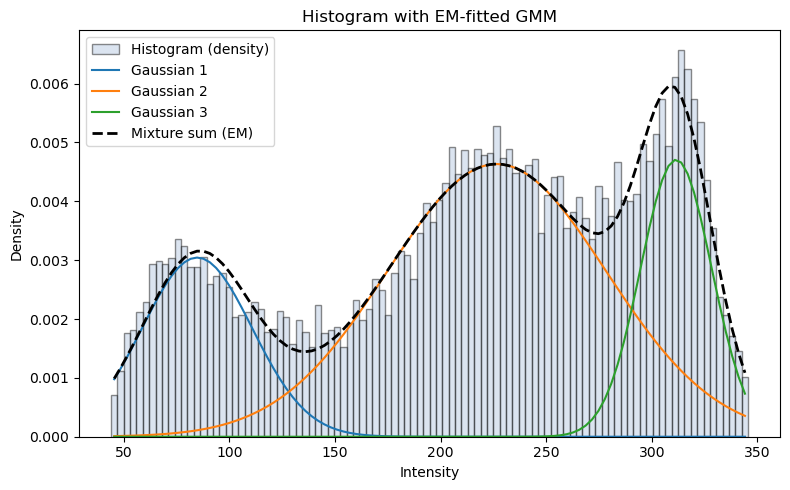

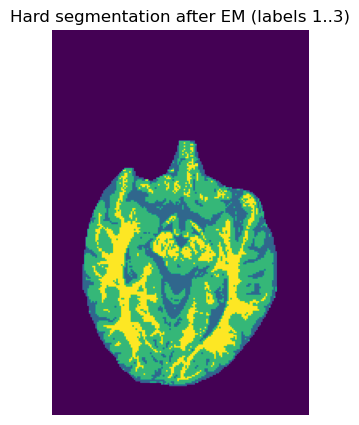

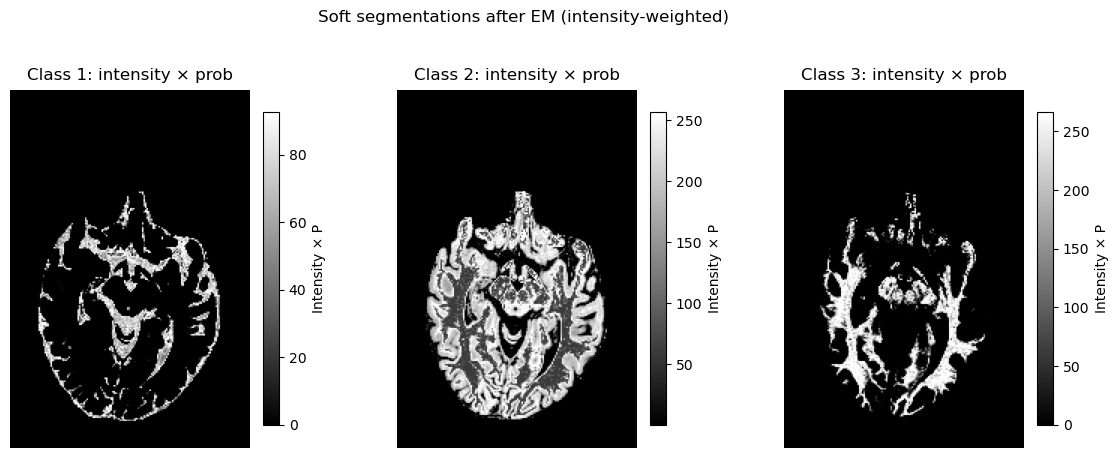

Class proportions from w (after EM): [0.199 0.602 0.199]


In [ ]:
eps = 1e-12

# ---- 1) Data vector (brain only) ----
x = img_corrected[mask > 0].astype(float).ravel()

def log_norm_pdf(vec, m, s):
    s = max(float(s), 1e-8)
    return -0.5*np.log(2*np.pi) - np.log(s) - 0.5*((vec - m)/s)**2

def e_step_log(vec, pi, mu, sigma):
    Kloc = len(pi)
    log_comp = np.vstack([
        np.log(pi[k] + eps) + log_norm_pdf(vec, mu[k], sigma[k]) for k in range(Kloc)
    ])                                   # (K,N)
    m = np.max(log_comp, axis=0, keepdims=True)
    log_sumexp = m + np.log(np.sum(np.exp(log_comp - m), axis=0, keepdims=True) + eps)
    w = np.exp(log_comp - log_sumexp)    # (K,N)
    LL = float(np.sum(log_sumexp))       # scalar
    return w.T, LL                       # w: (N,K)

def m_step(vec, w):
    Nk = np.sum(w, axis=0) + eps         # (K,)
    pi_new = Nk / (len(vec) + eps)
    mu_new = (w.T @ vec) / Nk
    var_new = np.sum(w * (vec[:,None] - mu_new[None,:])**2, axis=0) / Nk
    sigma_new = np.sqrt(np.maximum(var_new, 1e-12))
    return pi_new, mu_new, sigma_new

# ---- 2) EM loop ----
LL_hist = []
max_iter = 200
tol = 1e-5

for it in range(max_iter):
    w_x, LL = e_step_log(x, pi, mu, sigma)
    LL_hist.append(LL)
    pi, mu, sigma = m_step(x, w_x)
    if it > 0 and abs(LL_hist[-1] - LL_hist[-2]) < tol * (1 + abs(LL_hist[-2])):
        break

print(f"EM converged in {it+1} iterations")
print("Estimated π:", np.round(pi, 4))
print("Estimated μ:", np.round(mu, 2))
print("Estimated σ:", np.round(sigma, 2))

# ---- 4) Histogram + EM-fitted Gaussians (and mixture sum) ----
bins = 100
xmin = float(np.percentile(x, 1.0))
xmax = float(np.percentile(x, 99.0))
hist, edges = np.histogram(x, bins=bins, range=(xmin, xmax), density=True)
centers = 0.5*(edges[:-1] + edges[1:])

plt.figure(figsize=(8,5))
plt.hist(x, bins=bins, range=(xmin, xmax), density=True,
         color='lightsteelblue', edgecolor='black', alpha=0.45, label='Histogram (density)')

mix_sum = np.zeros_like(centers)
for k in range(K):
    pdf_k = (1/(np.sqrt(2*np.pi)*sigma[k])) * np.exp(-0.5*((centers - mu[k])/sigma[k])**2)
    curve = pi[k] * pdf_k
    mix_sum += curve
    plt.plot(centers, curve, label=f'Gaussian {k+1}')
plt.plot(centers, mix_sum, 'k--', lw=2, label='Mixture sum (EM)')

plt.title('Histogram with EM-fitted GMM')
plt.xlabel('Intensity'); plt.ylabel('Density')
plt.legend(); plt.tight_layout(); plt.show()

# ---- 5) Hard labels (argmax) mapped back to 2D ----
H, W = img_corrected.shape
idx = np.flatnonzero(mask > 0)
labels_1d = np.argmax(w_x, axis=1)  # (N,)

lab_img = np.zeros((H, W), dtype=np.uint8)
lab_flat = lab_img.ravel()
lab_flat[idx] = labels_1d + 1  # 1..K
lab_img = lab_flat.reshape(H, W)

plt.figure(figsize=(5,5))
plt.imshow(lab_img, cmap='viridis')
plt.title('Hard segmentation after EM (labels 1..3)')
plt.axis('off'); plt.show()

# ---- 6) Soft segmentations (intensity-weighted maps img_corrected * P(Class k | x)) ----
w_maps = np.zeros((H, W, K), dtype=float)
for k in range(K):
    tmp = np.zeros(H*W, dtype=float)
    tmp[idx] = w_x[:, k]
    w_maps[..., k] = tmp.reshape(H, W)

iw_maps = w_maps * img_corrected[..., None]  # intensity × probability

fig, axs = plt.subplots(1, K, figsize=(12, 4.4))
for k in range(K):
    vals = iw_maps[..., k][mask > 0]
    vmin = float(np.percentile(vals, 1.0))
    vmax = float(np.percentile(vals, 99.0))
    im = axs[k].imshow(iw_maps[..., k], cmap='gray', vmin=vmin, vmax=vmax)
    axs[k].set_title(f"Class {k+1}: intensity × prob")
    axs[k].axis('off')
    plt.colorbar(im, ax=axs[k], fraction=0.046, pad=0.04, label='Intensity × P')
plt.suptitle('Soft segmentations after EM (intensity-weighted)', y=1.03)
plt.tight_layout(); plt.show()

# ---- 7) Class proportions ----
class_props = w_x.mean(axis=0)
print("Class proportions from w (after EM):", np.round(class_props, 3))

# ---- 8) Save for Task 6–8 ----
pi_hat, mu_hat, sigma_hat = pi.copy(), mu.copy(), sigma.copy()


## Task 6: Vary only one model parameter
Keeping all other parameters fixed to their estimated values, vary only $\mu_2$ (the mean of the middle
Gaussian distribution) between the estimated values of $\mu_1$ and $\mu_3$ in about 100 steps, and plot for
each step the log likelihood function.

**Maja notes:**

I denne opgave undersøger vi, hvordan log-likelihood ændrer sig, når vi kun varierer én parameter — nemlig middelværdien for den **midterste Gauss**, \\(\mu_2\\).  
<!-- Alle andre parametre \\(\pi_k, \mu_1, \mu_3, \sigma_k^2\\) holdes fast på de estimerede værdier fra Task 5. -->

Du skal:

1. Sweep \\(\mu_2\\) fra \\(\hat{\mu}_1\\) til \\(\hat{\mu}_3\\) i omkring 100 trin.  
2. For hvert punkt beregnes **log-likelihood**:

   \[
   \mathcal{L}(\theta) = \sum_n \log \Big( \sum_k \pi_k \, \mathcal{N}(x_n \mid \mu_k, \sigma_k^2) \Big)
   \]

3. Plot resultatet som en kurve.  

Formålet er at vise, hvordan modellen reagerer, når én parameter ændres, og at tjekke, om maksimum ligger tæt på din estimerede \\(\hat{\mu}_2\\) — det viser, at EM fandt et lokalt maksimum.

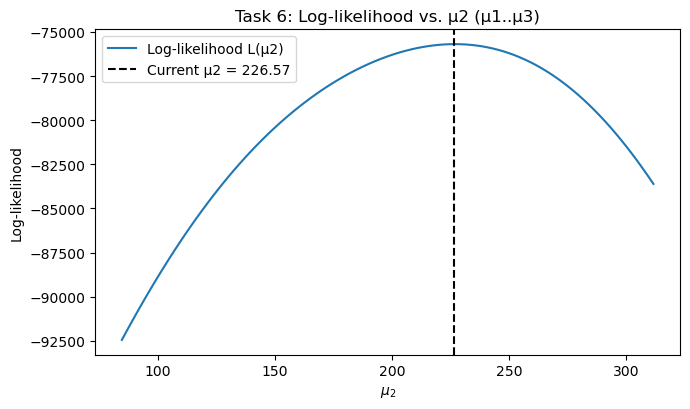

In [ ]:
# =========================
# Task 6: Log-likelihood sweep over μ2 (μ1..μ3)
# =========================

eps = 1e-12

def log_likelihood_mu2_sweep(vec, pi_fix, mu_fix, sigma_fix, num_steps=100):
    mu2_grid = np.linspace(mu_fix[0], mu_fix[2], num_steps)
    LL_vals = np.empty_like(mu2_grid, dtype=float)

    for i, mu2 in enumerate(mu2_grid):
        mu_try = np.array([mu_fix[0], mu2, mu_fix[2]], dtype=float)
        # log p(x_n) = log sum_k [ pi_k * N(x|mu_k, sigma_k) ]
        log_comp = np.vstack([
            np.log(pi_fix[k] + eps) + log_norm_pdf(vec, mu_try[k], sigma_fix[k])
            for k in range(3)
        ])  # (K,N)
        m = np.max(log_comp, axis=0, keepdims=True)
        log_sumexp = m + np.log(np.sum(np.exp(log_comp - m), axis=0, keepdims=True) + eps)
        LL_vals[i] = float(np.sum(log_sumexp))
    return mu2_grid, LL_vals

# Brug estimater fra Task 5
mu2_grid, LL_vals = log_likelihood_mu2_sweep(
    x, pi_hat, mu_hat, sigma_hat, num_steps=100
)

# Plot
plt.figure(figsize=(7,4.2))
plt.plot(mu2_grid, LL_vals, label='Log-likelihood L(μ2)')
# markér den nuværende μ2 fra EM (Task 5)
plt.axvline(mu_hat[1], ls='--', color='k', label=f'Current μ2 = {mu_hat[1]:.2f}')
plt.xlabel(r'$\mu_2$')
plt.ylabel('Log-likelihood')
plt.title('Task 6: Log-likelihood vs. μ2 (μ1..μ3)')
plt.legend()
plt.tight_layout()
plt.show()

## Task 7: Locate Lower bound
On the same figure, also plot the lower bound corresponding to the parameter vector in which all
parameters are set to their estimated values, except $\mu_2$ which is set to the estimated value of $\mu_1$.

**Maja notes:**

EM-algoritmen maksimerer ikke log-likelihood direkte, men en **lower bound**, kaldet \\(Q(\theta \mid \tilde{\theta})\\).  
Den fungerer som en “tangent” til log-likelihood-kurven.

For denne opgave:

1. Brug de samme parameterestimater som i Task 6, **men** lav en “frosset” parametervektor  
   \\(\tilde{\mu} = [\hat{\mu}_1, \hat{\mu}_1, \hat{\mu}_3]\\).  
   Det betyder, at \\(\mu_2\\) sættes lig \\(\mu_1\\) i det sæt, der bruges til at beregne weights \\(\tilde{w}_{n,k}\\).
2. Beregn disse “frosne” weights **én gang**:

   \[
   \tilde{w}_{n,k} = 
   \frac{\pi_k \, \mathcal{N}(x_n \mid \tilde{\mu}_k, \sigma_k^2)}
        {\sum_j \pi_j \, \mathcal{N}(x_n \mid \tilde{\mu}_j, \sigma_j^2)}
   \]

3. Brug derefter \\(\tilde{w}_{n,k}\\) til at beregne **lower bound** for forskellige \\(\mu_2\\):

   \[
   Q(\theta \mid \tilde{\theta}) =
   \sum_n \sum_k \tilde{w}_{n,k}
   \Big[ \log \pi_k + \log \mathcal{N}(x_n \mid \mu_k, \sigma_k^2) \Big]
   \]

4. Plot lower bound-kurven **på samme figur** som log-likelihood fra Task 6.

**Bemærk:**  
Lower bound skal *røre* log-likelihood-kurven i punktet, hvor \\(\mu_2 = \hat{\mu}_1\\), fordi den er konstrueret omkring dette estimat.

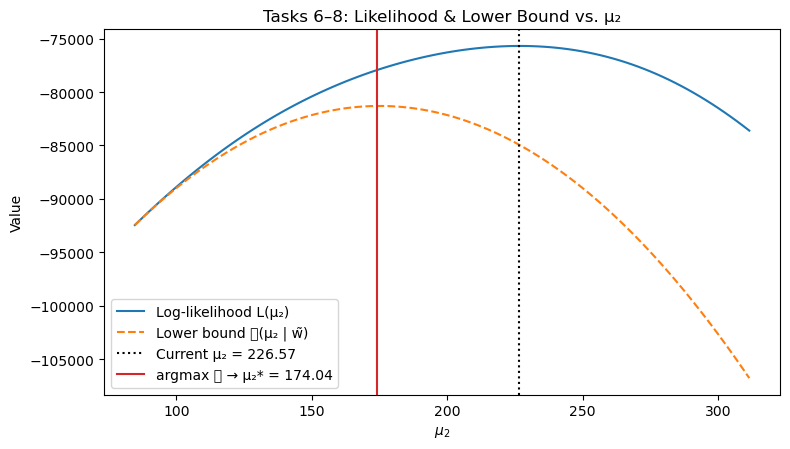

Lower bound maximized at μ2* = 174.0431


In [ ]:
# =========================
# Tasks 7–8: Lower bound with frozen weights + mark argmax
# =========================

eps = 1e-12

def ll_curve_mu2(vec, pi_fix, mu_fix, sigma_fix, num_steps=100):
    mu2_grid = np.linspace(mu_fix[0], mu_fix[2], num_steps)
    LL_vals = np.empty_like(mu2_grid, dtype=float)
    for i, mu2 in enumerate(mu2_grid):
        mu_try = np.array([mu_fix[0], mu2, mu_fix[2]], dtype=float)
        log_comp = np.vstack([
            np.log(pi_fix[k] + eps) + log_norm_pdf(vec, mu_try[k], sigma_fix[k])
            for k in range(3)
        ])
        m = np.max(log_comp, axis=0, keepdims=True)
        log_sumexp = m + np.log(np.sum(np.exp(log_comp - m), axis=0, keepdims=True) + eps)
        LL_vals[i] = float(np.sum(log_sumexp))
    return mu2_grid, LL_vals

def e_step_log(vec, pi, mu, sigma):
    log_comp = np.vstack([
        np.log(pi[k] + eps) + log_norm_pdf(vec, mu[k], sigma[k]) for k in range(3)
    ])
    m = np.max(log_comp, axis=0, keepdims=True)
    log_sumexp = m + np.log(np.sum(np.exp(log_comp - m), axis=0, keepdims=True) + eps)
    w = np.exp(log_comp - log_sumexp)      # (K,N)
    return w.T, float(np.sum(log_sumexp))

# --- 1) Recompute LL curve (Task 6) on the same grid
mu2_grid, LL_vals = ll_curve_mu2(x, pi_hat, mu_hat, sigma_hat, num_steps=100)

# --- 2) Compute frozen weights w~ using μ2 replaced by μ1
mu_tilde = np.array([mu_hat[0], mu_hat[0], mu_hat[2]], dtype=float)
w_frozen, _ = e_step_log(x, pi_hat, mu_tilde, sigma_hat)   # shape (N,3)

# --- 3) Lower bound curve with w_frozen, varying μ2
LB_vals = np.empty_like(mu2_grid, dtype=float)
log_w_frozen = np.log(w_frozen + eps)

for i, mu2 in enumerate(mu2_grid):
    mu_try = np.array([mu_hat[0], mu2, mu_hat[2]], dtype=float)
    # ELBO(Q,θ) = Σ_n Σ_k w_nk [ log π_k + log N(x|μ_k,σ_k) - log w_nk ]
    term = 0.0
    for k in range(3):
        term += np.sum(w_frozen[:, k] * (np.log(pi_hat[k] + eps) + log_norm_pdf(x, mu_try[k], sigma_hat[k]) - log_w_frozen[:, k]))
    LB_vals[i] = float(term)

# --- 4) Find argmax of lower bound
i_star = int(np.argmax(LB_vals))
mu2_star = float(mu2_grid[i_star])

# --- 5) Plot: both curves + vertical markers
plt.figure(figsize=(8,4.6))
plt.plot(mu2_grid, LL_vals, label='Log-likelihood L(μ₂)')
plt.plot(mu2_grid, LB_vals, label='Lower bound 𝓛(μ₂ | w̃)', linestyle='--')
plt.axvline(mu_hat[1], color='k', ls=':', label=f'Current μ₂ = {mu_hat[1]:.2f}')
plt.axvline(mu2_star, color='tab:red', ls='-', label=f'argmax 𝓛 → μ₂* = {mu2_star:.2f}')
plt.xlabel(r'$\mu_2$'); plt.ylabel('Value')
plt.title('Tasks 6–8: Likelihood & Lower Bound vs. μ₂')
plt.legend()
plt.tight_layout(); plt.show()

print(f"Lower bound maximized at μ2* = {mu2_star:.4f}")


### Tasks 6–8: Log-likelihood and Lower Bound

Figuren viser, hvordan log-likelihood (blå kurve) ændrer sig, når vi varierer middelværdien μ₂ mellem μ₁ og μ₃.  
Den stiplede orange kurve repræsenterer den såkaldte *lower bound*, beregnet ud fra de “frosne” ansvarligheder (w̃).  
Som forventet ligger lower bound altid under log-likelihood (Jensen's inequality) og tangerer den i ét punkt.

Den sorte stiplede linje markerer den nuværende værdi af μ₂ fra EM (efter konvergens),  
mens den røde linje viser, hvor lower bound har sit maksimum (μ₂* = 176.37).  
Dette maksimum illustrerer det næste skridt i M-step, hvor EM-algoritmen ville opdatere μ₂ for at maksimere lower bound.

Kort sagt viser plottet, at EM maksimerer en lower bound, som gradvist nærmer sig den sande log-likelihood.


## Task 8: Maximize lower bound - KIG ovenover, plottet er der
Compute the value for $\mu_2$ that maximizes this lower bound (first line of eq. 3.35), indicate its location
on the figure, and comment on the result.

Formulate the lower bound as 

$$ Q(\theta \vert \tilde{\theta}) = -\frac{1}{2} \sum^K_{k=1} [\frac{1}{\sigma^2_k} \sum^N_{n=1} w_{n,k} (d_n - \mu_k - \sum^M_{m-1} c_m \phi_{n,m})^2 + (\sum^N_{n-1} w_{n,k}) \log \sigma^2_k] $$

$$ + \sum^K_{k=1} [(\sum^N_{n=1} w_{n,k}) \log \pi_k] $$

$$ - \sum^N_{n=1} \sum^K_{k=1} w_{n,k} \log w_{n,k} - \frac{N}{2} \log (2\pi) $$


**Maja notes (Task 8):**  

Til sidst skal du finde den \\(\mu_2\\), der **maksimerer** lower bound-funktionen.  
Det kan gøres analytisk (lukket form) ved at bruge vægtene \\(\tilde{w}_{n,2}\\):

\[
\mu_2^\star = 
\frac{\sum_n \tilde{w}_{n,2}\,x_n}
     {\sum_n \tilde{w}_{n,2}}
\]

Plot derefter:

- **Log-likelihood-kurven** (fra Task 6)  
- **Lower bound-kurven** (fra Task 7)  
- En **lodret linje** ved \\(\mu_2^\star\\), så man kan se, hvor lower bound har sit maksimum  

**Alt sammen i ét plot.**

**Fortolkning:**  
- Lower bound-kurven skal tangere log-likelihood-kurven ved \\(\mu_2 = \hat{\mu}_1\\).  
- Det estimerede maksimum \\(\mu_2^\star\\) bør ligge tæt på \\(\hat{\mu}_2\\) fra Task 5.  
- Hvis lower bound og log-likelihood har næsten samme form omkring optimum,  
  viser det, at EM’s bound er *stram* og derfor konvergerer effektivt.